In [51]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

In [52]:

def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    keep = [c for c in df.columns if '_r_avg_1' in c or c == 'season']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    keep = list(dict.fromkeys(keep + numeric_cols))
    drop_cols = [c for c in df.columns if (df[c].dtype == object or 'id' in c or 'name' in c or 'team' in c) and c not in keep]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df.loc[:, [c for c in df.columns if c in keep or df[c].dtype != object]]

def choose_target(columns):
    if 'fantasy_points_r_avg_1' in columns:
        return 'fantasy_points_r_avg_1'
    if 'fantasy_points' in columns:
        return 'fantasy_points'
    for c in columns:
        if 'fantasy_points' in c:
            return c
    return None

In [59]:
sns.set_theme(style="whitegrid")
DATA_CSV = Path('../dataset_generators/datasets/final_1_lag_ffa_dataset.csv')


df = pd.read_csv(DATA_CSV)
print('Dataset shape:', df.shape)
print('Columns sample:', df.columns.tolist()[:40])

TARGET = choose_target(list(df.columns))
if TARGET is None:
    raise RuntimeError('No fantasy-points-like target found in dataset; edit choose_target or set TARGET manually.')
print('Selected target column:', TARGET)


# display(df[TARGET].describe())
# plt.figure(figsize=(8,3))
# sns.histplot(df[TARGET].dropna(), bins=50)

Dataset shape: (60969, 78)
Columns sample: ['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'season', 'week', 'season_type', 'team', 'opponent_team', 'age', 'years_exp', 'passing_yards_r_avg_1_lag_1', 'passing_yards_r_avg_3_lag_1', 'passing_yards_r_avg_5_lag_1', 'passing_yards_r_avg_8_lag_1', 'passing_tds_r_avg_1_lag_1', 'passing_tds_r_avg_3_lag_1', 'passing_tds_r_avg_5_lag_1', 'passing_tds_r_avg_8_lag_1', 'passing_interceptions_r_avg_1_lag_1', 'passing_interceptions_r_avg_3_lag_1', 'passing_interceptions_r_avg_5_lag_1', 'passing_interceptions_r_avg_8_lag_1', 'passing_2pt_conversions_r_avg_1_lag_1', 'passing_2pt_conversions_r_avg_3_lag_1', 'passing_2pt_conversions_r_avg_5_lag_1', 'passing_2pt_conversions_r_avg_8_lag_1', 'sack_fumbles_lost_r_avg_1_lag_1', 'sack_fumbles_lost_r_avg_3_lag_1', 'sack_fumbles_lost_r_avg_5_lag_1', 'sack_fumbles_lost_r_avg_8_lag_1', 'rushing_yards_r_avg_1_lag_1', 'rushing_yards_r_avg_3_lag_1', 'rushing_yards_r_av

In [60]:

df_proc = preprocess_df(df)
if TARGET not in df_proc.columns:
    df_proc[TARGET] = df[TARGET]

X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]

drop_ravg_other = [col for col in X.columns if 'r_avg_lag_1' in col and 'r_avg_1_lag_1' not in col]
if drop_ravg_other:
    print('Dropping non-1-window r_avg columns:', drop_ravg_other)
    X = X.drop(drop_ravg_other, axis=1)

protected = [col for col in X.columns if 'r_avg_1_lag_1' in col or col == 'season']
dropCols = [col for col in X.columns if (X[col].dtype == 'object' or 'id' in col or 'name' in col or 'team' in col) and col not in protected]
if dropCols:
    X = X.drop(dropCols, axis=1)

X = X.select_dtypes(include=[np.number])
print('Numeric feature count:', X.shape[1])

X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
print('Trained LinearRegression on', X_train.shape[0], 'rows and', X_train.shape[1], 'features')

Numeric feature count: 62
Trained LinearRegression on 48775 rows and 62 features
Trained LinearRegression on 48775 rows and 62 features


In [61]:

preds = model.predict(X_test_scaled)
r2 = metrics.r2_score(y_test, preds)
mse = metrics.mean_squared_error(y_test, preds)
rmse = mse ** 0.5
print(f'R^2: {r2:.4f}, RMSE: {rmse:.4f}')

results = X_test.copy()
results['y_true'] = y_test.values
results['y_pred_cont'] = preds
results = results.reset_index(drop=True)
results.head()

R^2: 0.4039, RMSE: 5.3923


,season,week,age,years_exp,passing_yards_r_avg_1_lag_1,passing_yards_r_avg_3_lag_1,passing_yards_r_avg_5_lag_1,passing_yards_r_avg_8_lag_1,passing_tds_r_avg_1_lag_1,passing_tds_r_avg_3_lag_1,...,receiving_2pt_conversions_r_avg_5_lag_1,receiving_2pt_conversions_r_avg_8_lag_1,fantasy_points_r_avg_1_lag_1,fantasy_points_r_avg_3_lag_1,fantasy_points_r_avg_5_lag_1,fantasy_points_r_avg_8_lag_1,opp_team_dst_fp_r_avg_1_lag_1,opp_team_dst_fp_rank_r_avg_1_lag_1,y_true,y_pred_cont
0,2018,13,24,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,12.3,9.53,10.58,10.80,1.0,26.5,10.8,10.302431
1,2015,13,29,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.6,4.60,4.60,4.60,21.0,1.0,0.2,6.000781
2,2019,14,25,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.3,0.57,1.56,1.54,9.0,11.0,0.4,2.775503
3,2017,4,27,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.40,1.40,1.40,-1.0,30.5,6.8,3.232861
4,2016,15,27,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.5,6.37,4.46,3.32,18.0,2.5,7.0,4.402964


In [62]:

results['y_true_round'] = results['y_true'].round().astype(int)
results['y_pred_round'] = results['y_pred_cont'].round().astype(int)


n_bins = 3
labels = [f'bin_{i}' for i in range(n_bins)]
results['y_true_q'] = pd.qcut(results['y_true'], q=n_bins, labels=labels, duplicates='drop')
results['y_pred_q'] = pd.qcut(results['y_pred_cont'], q=n_bins, labels=labels, duplicates='drop')


true_col = 'y_true_q'
pred_col = 'y_pred_q'
print('Using', true_col, 'vs', pred_col)
results[[true_col, pred_col]].head()

Using y_true_q vs y_pred_q


,y_true_q,y_pred_q
0,bin_2,bin_2
1,bin_0,bin_1
2,bin_0,bin_0
3,bin_2,bin_0
4,bin_2,bin_1


Labels order: ['bin_0', 'bin_1', 'bin_2']
              precision    recall  f1-score   support

       bin_0       0.65      0.65      0.65      4067
       bin_1       0.45      0.45      0.45      4077
       bin_2       0.64      0.64      0.64      4050

    accuracy                           0.58     12194
   macro avg       0.58      0.58      0.58     12194
weighted avg       0.58      0.58      0.58     12194

              precision    recall  f1-score   support

       bin_0       0.65      0.65      0.65      4067
       bin_1       0.45      0.45      0.45      4077
       bin_2       0.64      0.64      0.64      4050

    accuracy                           0.58     12194
   macro avg       0.58      0.58      0.58     12194
weighted avg       0.58      0.58      0.58     12194



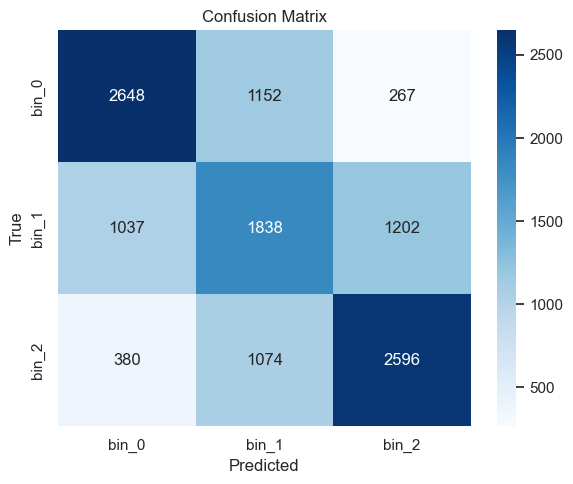

In [63]:

y_true_cat = results[true_col].astype(str)
y_pred_cat = results[pred_col].astype(str)
labels_order = sorted(list(set(y_true_cat) | set(y_pred_cat)))
cm = confusion_matrix(y_true_cat, y_pred_cat, labels=labels_order)
print('Labels order:', labels_order)
print(classification_report(y_true_cat, y_pred_cat, labels=labels_order))

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [64]:

results['abs_err'] = (results['y_true'] - results['y_pred_cont']).abs()
top = results.sort_values('abs_err', ascending=False).head(20)[['y_true','y_pred_cont', true_col, pred_col,'abs_err']]
top.reset_index(drop=True)
top

,y_true,y_pred_cont,y_true_q,y_pred_q,abs_err
3034,53.20,11.387478,bin_2,bin_2,41.812522
3486,47.80,7.059880,bin_2,bin_2,40.740120
7040,35.50,3.731376,bin_2,bin_1,31.768624
6642,37.80,6.568359,bin_2,bin_1,31.231641
7790,39.70,8.468659,bin_2,bin_2,31.231341
5772,41.60,10.438903,bin_2,bin_2,31.161097
4818,37.00,6.059652,bin_2,bin_1,30.940348
6910,34.08,4.602057,bin_2,bin_1,29.477943
8361,33.50,4.751113,bin_2,bin_1,28.748887
6717,34.70,6.650461,bin_2,bin_1,28.049539
